In [1]:
# Import ettiğimiz dosyalarda değişiklik yaptığımızda her seferinde yeniden yüklesin.

%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import gc
import warnings
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

In [3]:
from src.analyze_model import (
    check_calibration,
    create_risk_buckets,
    display_styled_risk_report,
    plot_cm_with_optimal_pr_threshold
)
from src.calibration import isotonic_calibrator_catboost
from src.feature_selection import (
    custom_rfe_with_early_stopping,
    perform_nan_safe_boruta,
    select_features_with_beeswarm
)
from src.modelling import (
    calculate_precision_at_k,
    calculate_recall_at_k,
    plot_catboost_importance,
    run_cross_validation
)
from src.tuning import run_optuna_study

/home/can/miniforge3/envs/teb_arf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configs

In [4]:
warnings.filterwarnings("ignore") # Warningleri filtreleyelim

In [5]:
pd.set_option("display.max_columns",None) # Tüm sütunları görelim

# Constants

In [6]:
SEED = 42
TARGET_COL = "Target"
K_FOLD = 3

# Read Data

In [7]:
df = pd.read_csv("data/processed/processed.csv")
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [8]:
# veriyi stratified, train ve test olarak ikiye ayıralım.
# X_test ve y_test bizim OOF(Out of Fold) setimiz olacak.

X_train, X_test, y_train, y_test = train_test_split(X,
                                     y,
                                     test_size=0.2,
                                     shuffle=True,
                                     random_state=SEED,
                                     stratify=y)

train_df = pd.concat([X_train, y_train], axis=1)

del X, y, df, X_train, y_train# ihtiyacımız olmayacak
gc.collect()

20

In [9]:
train_df.shape

(27389, 64)

In [10]:
# Değişken listesini elde edelim. İleride eleme yapacağız.

features = train_df.drop(columns=[TARGET_COL]).columns.tolist()

# Feature Elimination

## Boruta

Bir önceki notebook'ta **"Multicollinearity, Variance Inflation Factor"** ile değişken elemesi yapmıştık. <br>
Şimdi ikinci aşama olarak **Boruta** ile eleme yapalım.  
XGBoost çok hızlı olduğu için XGBoost ile hızlıca eleme yapacağız.  
100 iterasyon bizim için gayet yeterli olacaktır.

Boruta Nasıl Çalışır?

- **Shadow Features**: Elindeki her değişkenin değerlerini rastgele karıştırarak (shuffle) "çöp" kopyalarını oluşturur.

- **Yarışma**: Orijinal değişkenleri bu çöp kopyalarla (shadow) aynı modelde yarıştırır.

- **Kıyas**: Gölge değişkenlerin en iyisinden bile daha kötü performans gösteren orijinalleri "gereksiz" olarak işaretler.

- **Karar**: Bu işlemi defalarca tekrarlar ve istatistiksel olarak (Binom testi) gölgeleri istikrarlı şekilde yenenleri "gerçek sinyal" olarak kabul eder.

Avantajları

- **Rastlantısallığı Elenir**: Bir değişkenin şans eseri mi yoksa gerçekten mi önemli olduğunu istatistiksel olarak kanıtlar.

- **Karmaşık İlişkileri Yakalar**: Doğrusal olmayan ve değişkenler arasındaki etkileşimleri (interactions) dikkate alır.

- **Parametresiz Güven**: Değişken seçimi için bir eşik değeri (threshold) belirleme zahmetinden kurtarır, kararı istatistiğe bırakır.

Dezavantajları

- **Multicollinearity Sorunu**: Birbirinin aynısı olan (korele) değişkenleri elemez; sinyal taşıdıkları sürece hepsini tutar.

In [11]:
boruta_report = perform_nan_safe_boruta(
    train_df,
    features,
    TARGET_COL,
    "XGBoost", 
    n_iterations=100, 
    random_state=SEED)

İşlem başlatılıyor: 100 iterasyon...
İterasyon 10 tamamlandı.
İterasyon 20 tamamlandı.
İterasyon 30 tamamlandı.
İterasyon 40 tamamlandı.
İterasyon 50 tamamlandı.
İterasyon 60 tamamlandı.
İterasyon 70 tamamlandı.
İterasyon 80 tamamlandı.
İterasyon 90 tamamlandı.
İterasyon 100 tamamlandı.


In [12]:
boruta_report

,Feature,Hits,Hit_Ratio,Status
0,Var_4,100.0,1.00,Confirmed
1,Var_5,100.0,1.00,Confirmed
2,Var_6,100.0,1.00,Confirmed
3,Var_7,100.0,1.00,Confirmed
4,Var_10,100.0,1.00,Confirmed
...,...,...,...,...
48,Var_36_3,2.0,0.02,Rejected
24,Var_40,0.0,0.00,Rejected
35,Var_2_U,0.0,0.00,Rejected
32,Var_2_6,0.0,0.00,Rejected


In [13]:
# Confirmed ve Tentative değişkenler ile yola devam edelim.

selected_features = boruta_report.query("Status == 'Confirmed'")["Feature"].tolist() # Yalnızca Boruta testinden geçenleri alalım.

In [14]:
remaining_count = len(selected_features)
total_count = len(features)
removed_count = total_count - remaining_count
removal_ratio = (removed_count / total_count) * 100

print(
    f"BORUTA sonucu kalan değişken sayısı: {remaining_count}\n"
    f"BORUTA sonucu elenen değişken sayısı: {removed_count}\n"
    f"BORUTA sonucu elenen değişken oranı: ~%{int(removal_ratio)}"
)

BORUTA sonucu kalan değişken sayısı: 41
BORUTA sonucu elenen değişken sayısı: 22
BORUTA sonucu elenen değişken oranı: ~%34


## RFE

**Early Stopping Destekli Özel RFE (Recursive Feature Elimination)**

Modelin karmaşıklığını azaltmak ve genelleme kapasitesini (generalization) artırmak için Recursive Feature Elimination (RFE) yöntemini kullandım. Ancak standart RFE yaklaşımlarından farklı olarak, süreci daha robust hale getiren üç kritik modifikasyon ekledim:

Erken Durdurma

- Standart RFE genellikle sabit iterasyonlu modeller kullanır. Bu fonksiyonda, XGBoost'un Early Stopping özelliğini kullanarak her değişken kümesi için modelin en optimal noktada durmasını sağladım. Bu, elenen değişkenlerin **yetersiz eğitim** nedeniyle değil, gerçekten düşük açıklayıcılık gücü nedeniyle elendiğinden emin olmamızı sağlar.

Cross-Validation Entegrasyonu

- Değişken önem skorları tek bir eğitim setine göre değil, 3-Fold Stratified Cross-Validation üzerinden hesaplanır. Bu sayede, verideki rastlantısal gürültüye değil, katmanlar arasında tutarlı olan sinyale dayalı bir eleme yapılır.

Çok Kriterli İzleme: Gini ve PR-AUC

- Eleme süreci boyunca iki ana metrik takip edilir:

    - Gini Katsayısı: Modelin genel ayrıştırma gücünü ölçmek için.

    - PR-AUC (Precision-Recall AUC): Dengesiz veri setlerinde (imbalanced data) modelin azınlık sınıfı (target=1) yakalama başarısını izlemek için.

In [15]:
rfe_results = custom_rfe_with_early_stopping(train_df[selected_features],
                                             train_df[TARGET_COL],
                                             step=1, # her döngüde 1 değişken ele
                                             n_splits=K_FOLD)

Features: 41 -> Gini: 0.5306 -> PR_AUC 0.1457 | Removed: ['Var_45_Y']
Features: 40 -> Gini: 0.5306 -> PR_AUC 0.1457 | Removed: ['Var_50_Y']
Features: 39 -> Gini: 0.5306 -> PR_AUC 0.1457 | Removed: ['Var_49_Y']
Features: 38 -> Gini: 0.5306 -> PR_AUC 0.1457 | Removed: ['Var_44_Y']
Features: 37 -> Gini: 0.5306 -> PR_AUC 0.1457 | Removed: ['Var_2_4']
Features: 36 -> Gini: 0.5327 -> PR_AUC 0.1467 | Removed: ['Var_14_Y']
Features: 35 -> Gini: 0.5327 -> PR_AUC 0.1472 | Removed: ['Var_14_N']
Features: 34 -> Gini: 0.5322 -> PR_AUC 0.1477 | Removed: ['Var_35_Y']
Features: 33 -> Gini: 0.5311 -> PR_AUC 0.1462 | Removed: ['Var_46']
Features: 32 -> Gini: 0.5289 -> PR_AUC 0.1455 | Removed: ['Var_36_X']
Features: 31 -> Gini: 0.5289 -> PR_AUC 0.1446 | Removed: ['Var_48_Y']
Features: 30 -> Gini: 0.5264 -> PR_AUC 0.1443 | Removed: ['Var_31']
Features: 29 -> Gini: 0.5280 -> PR_AUC 0.1443 | Removed: ['Var_2_3']
Features: 28 -> Gini: 0.5311 -> PR_AUC 0.1456 | Removed: ['Var_30']
Features: 27 -> Gini: 0.5286

En iyi değerleri **19** değişkenle elde ediyoruz.

In [16]:
selected_features = rfe_results.loc[rfe_results['n_features'] == 19, 'features'].values[0]

print(f"Seçilen Değişken Sayısı: {len(selected_features)}")
print("Değişken Listesi:")
print(selected_features)

Seçilen Değişken Sayısı: 19
Değişken Listesi:
['Var_4', 'Var_5', 'Var_6', 'Var_7', 'Var_10', 'Var_12', 'Var_13', 'Var_16', 'Var_18', 'Var_19', 'Var_20', 'Var_24', 'Var_42', 'Var_25', 'Var_41', 'Var_34', 'Var_36_2', 'Var_2_L', 'Var_33']


## SHAP Based Elemination

**Global Açıklanabilirlik: SHAP Beeswarm Analizi**

Modelin tahminleme mantığını tamamen şeffaf hale getirmek ve değişkenlerin hedef değişken üzerindeki etkisini görselleştirmek için SHAP metodolojisini kullandım.

Sadece "hangi değişken önemli?" sorusuna değil, "bir değişkenin değeri arttığında risk nasıl değişiyor?" sorusuna da cevap aradığım bu aşamada Beeswarm  grafiğini tercih ettim.

Neden SHAP ile eleme?

Geleneksel "Feature Importance" tabloları bize sadece bir değişkenin ne kadar önemli olduğunu söyler ama bu önemin yönünü (pozitif/negatif) göstermez. Tasarladığım bu fonksiyon ile:

- **Cross-Validation ile Stabilite:** SHAP değerlerini tüm CV fold'ları üzerinden hesaplayarak, değişken etkilerinin verinin farklı segmentlerinde ne kadar tutarlı olduğunu ölçtüm.

- **Yönlü Analiz:** Grafik üzerindeki renkler (Kırmızı: Yüksek değer, Mavi: Düşük değer) ve yatay eksen (Risk üzerindeki etki), değişkenlerin marjinal etkisini net bir şekilde ortaya koyar.

SHAP Beeswarm Grafiği Nasıl Okunmalı?
- **Sıralama (Dikey Eksen):** Değişkenler en yukarıdan aşağıya doğru önem sırasına dizilir.

- **Renk Paleti:** Kırmızı noktalar ilgili değişkenin yüksek değerlerini, mavi noktalar ise düşük değerlerini temsil eder.

- **Yatay Eksen (SHAP Value):** Eğer kırmızı noktalar sağ tarafta (pozitif bölge) kümeleniyorsa, bu değişkenin değeri arttıkça modelin Target=1 (Temerrüt/Risk) olasılığını artırdığı anlamına gelir.

- **Yoğunluk:** Noktaların dikey olarak şişkinleştiği yerler, verinin o bölgede yoğunlaştığını gösterir.

**Elenen Değişkenler:**

- **Var_25** : Kırmızı ve Mavi noktalar çok iç içe bu yüzden bize bir açıklayıcılık sağlamaz. 
- **Var_26** : Kırmızı ve Mavi noktalar çok iç içe bu yüzden bize bir açıklayıcılık sağlamaz. 
- **Var_36_2** : Kırmızı değerler hem artırıcı hem de azaltıcı etkiye sahip.
- **Var_24** : Kırmızı değerler hem artırıcı hem de azaltıcı etkiye sahip.
- **Var_33** : Mavi değerler em artırıcı hem de azaltıcı etkiye sahip.


--- SHAP Analizi ve CV Süreci Başladı (3 Fold) ---
Fold 1 tamamlandı.
Fold 2 tamamlandı.
Fold 3 tamamlandı.

--- Grafik Oluşturuluyor... ---


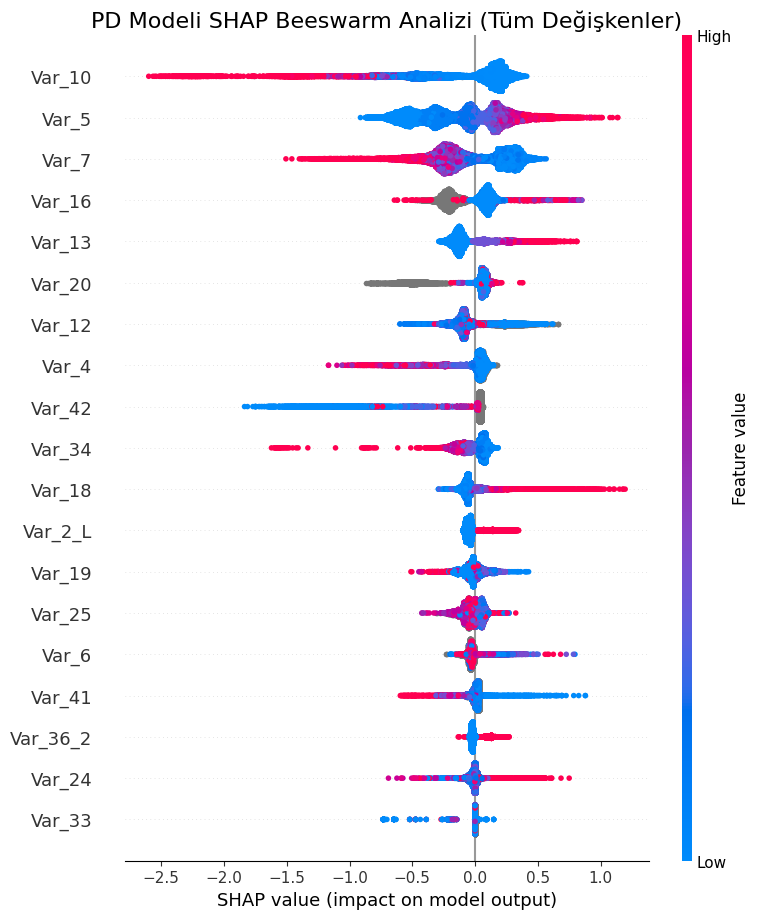

In [17]:
importance_table = select_features_with_beeswarm(train_df[selected_features], train_df[TARGET_COL])

In [18]:
drop_cols = {
             "Var_25",
             "Var_6",
             "Var_36_2",
             "Var_24",
             "Var_33"}

selected_features = list(set(selected_features) - drop_cols)

# Modelling


==================== Eğitiliyor: XGBoost ====================
Fold 1 | GINI-TRAIN: 0.6385 | GINI-VAL: 0.5266 |  PR-AUC-TRAIN: 0.1851 | PR-AUC-VAL: 0.1410 | R@10: 0.3195 | PR@10: 0.1522
Fold 2 | GINI-TRAIN: 0.6542 | GINI-VAL: 0.5441 |  PR-AUC-TRAIN: 0.1958 | PR-AUC-VAL: 0.1634 | R@10: 0.3333 | PR@10: 0.1588
Fold 3 | GINI-TRAIN: 0.6270 | GINI-VAL: 0.5244 |  PR-AUC-TRAIN: 0.1816 | PR-AUC-VAL: 0.1375 | R@10: 0.3272 | PR@10: 0.1557

==================== Eğitiliyor: LightGBM ====================
Fold 1 | GINI-TRAIN: 0.6632 | GINI-VAL: 0.5288 |  PR-AUC-TRAIN: 0.1945 | PR-AUC-VAL: 0.1375 | R@10: 0.3195 | PR@10: 0.1522
Fold 2 | GINI-TRAIN: 0.6550 | GINI-VAL: 0.5417 |  PR-AUC-TRAIN: 0.1933 | PR-AUC-VAL: 0.1544 | R@10: 0.3471 | PR@10: 0.1654
Fold 3 | GINI-TRAIN: 0.6593 | GINI-VAL: 0.5312 |  PR-AUC-TRAIN: 0.2016 | PR-AUC-VAL: 0.1383 | R@10: 0.3364 | PR@10: 0.1601

==================== Eğitiliyor: CatBoost ====================
Fold 1 | GINI-TRAIN: 0.5737 | GINI-VAL: 0.5448 |  PR-AUC-TRAIN: 0.1516 

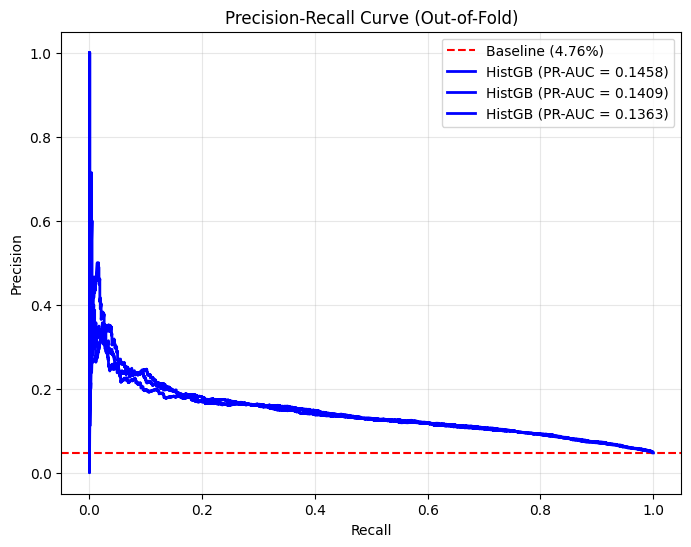

In [19]:
final_results = run_cross_validation(train_df[selected_features], train_df[TARGET_COL], K_FOLD)

$$\text{Recall}@k = \frac{\text{Üst dilimdeki Gerçek Pozitifler}}{\text{Veri setindeki Toplam Gerçek Pozitifler}}$$

$$\text{Precision}@k = \frac{\text{Üst dilimdeki Gerçek Pozitifler}}{\text{Üst dilimdeki Toplam Gözlem Sayısı (n)}}$$

$$\text{Lift} = \frac{\text{Precision@10}}{\text{Target Rate}}$$

CatBoost aralarındaki en stabil (fold dalgalanması düşük) ve en iyi performansı veren model

- Recall@10 değeri yaklaşık **~%33.2**. Sadece en riskli %10'luk dilimi inceleyerek, tüm riskli müşterilerin yaklaşık **~%33**'ünü tahmin edebiliyorum.

- Precision@10 değeri yaklaşık **%15.8**. En riskli %10'luk dilimde her 100 kişiden yaklaşık 16 kişi gerçekten default oluyor. Hiç model eğitmeseydik bu değer %4.5 olacaktı. **Lift(kaldıraç)** değeri yaklaşık olarak **%15.5** / **%4.5** = **3.51**. Yani model rastgele tahminden 3.5 kat daha iyi tahmin ediyor.

In [20]:
final_results.groupby("Model").agg("mean")

,Fold,Best_Iter,GINI_TRAIN,GINI_VAL,PR_AUC_TRAIN,PR_AUC_VAL,Recall@10,Precision@10,Diff
Model,,,,,,,,,
CatBoost,2.0,90.333333,0.566353,0.529293,0.153043,0.140542,0.328206,0.156315,0.012501
LightGBM,2.0,0.000000,0.659168,0.533908,0.196495,0.143401,0.334357,0.159241,0.053094
XGBoost,2.0,86.666667,0.639888,0.531692,0.187516,0.147290,0.326688,0.155588,0.040227


## Hyperparameter Tuning

**Optuna'nın Bayesian Yaklaşımının Avantajları**

- **Verimlilik:** Rastgele denemeler yapmak yerine, kayıp fonksiyonunu (objective function) minimize veya maksimize edecek en iyi noktayı matematiksel bir olasılık modeli (genellikle Tree-structured Parzen Estimator - TPE) ile tahmin eder.

- **Zaman Tasarrufu:** Kötü sonuç veren parametre uzaylarını hızlıca terk eder ve "vaat eden" bölgelerde daha derinlemesine arama yapar.

- **Budama (Pruning):** Düşük performans gösteren denemeleri henüz tamamlanmadan durdurarak hesaplama kaynaklarını boşa harcamaz.

**Gelişmiş Overfit Kontrolü**

Sadece performansa odaklanmak, modelin eğitim verisini ezberlemesine (overfitting) neden olabilir. Bu riski yönetmek için algoritmaya özel bir hata payı (gap) kontrolü ekledim:



```python gap: float = train_mean - val_mean
if gap > 0.03:
    return 0 

**Stratejik Kısıtlama:** Eğitim skoru ile doğrulama (validation) skoru arasındaki fark %3'ü geçtiği anda, model ne kadar yüksek PR-AUC alırsa alsın Optuna tarafından "başarısız" (0 puan) kabul edilir.

**Güvenilir Modeller:** Bu kısıtlama, Optuna'yı sadece "en yüksek skoru veren" parametrelere değil, "en yüksek skoru en dengeli şekilde veren" parametrelere yönlendirir. Böylece modelin production ortamında, görmediği veriler üzerinde de benzer performansı sergilemesi garanti altına alınır.

In [32]:
best_params = run_optuna_study(train_df[selected_features], train_df[TARGET_COL], n_trials=50, n_splits=K_FOLD)

[I 2026-02-07 22:45:21,834] A new study created in memory with name: CatBoost_Optimization


Optuna 50 deneme için CatBoost üzerinde başlatılıyor...


[I 2026-02-07 22:45:22,402] Trial 0 finished with value: 0.0 and parameters: {'iterations': 500, 'learning_rate': 0.08927180304353628, 'depth': 4, 'l2_leaf_reg': 6.681790353582674, 'random_strength': 0.02938027938703535, 'border_count': 66, 'scale_pos_weight': 2.103811344432631, 'bootstrap_type': 'Bayesian', 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.0.
[I 2026-02-07 22:45:22,679] Trial 1 finished with value: 0.1222715823287216 and parameters: {'iterations': 370, 'learning_rate': 0.015199348301309814, 'depth': 2, 'l2_leaf_reg': 3.691990689655602, 'random_strength': 0.3752055855124282, 'border_count': 128, 'scale_pos_weight': 6.534470339913863, 'bootstrap_type': 'Bayesian', 'grow_policy': 'Lossguide'}. Best is trial 1 with value: 0.1222715823287216.
[I 2026-02-07 22:45:23,027] Trial 2 finished with value: 0.1391446651173641 and parameters: {'iterations': 359, 'learning_rate': 0.032676417657817626, 'depth': 3, 'l2_leaf_reg': 2.196225615030479, 'random_strength': 0.6647135


--- OPTIMIZASYON TAMAMLANDI ---
En İyi PR-AUC: 0.1449


In [33]:
best_params

{'iterations': 432,
 'learning_rate': 0.014495102383254688,
 'depth': 4,
 'l2_leaf_reg': 10.190249933922802,
 'random_strength': 0.7947147424653744,
 'border_count': 227,
 'scale_pos_weight': 16.272851025795212,
 'bootstrap_type': 'Bernoulli',
 'grow_policy': 'Depthwise',
 'subsample': 0.5550259622638384}

Optuna sonucu elde ettiğimiz parametrelerle modeli eğitelim.

In [34]:
best_model = CatBoostClassifier(**best_params, verbose=0)
best_model.fit(train_df[selected_features], train_df[TARGET_COL])

## Feature Importance

Değişkenlerin dağılımı homojene yakın bu iyi haber çünkü canlıda bir değişken bozulursa modele etkisi çok fazla olmayacak.

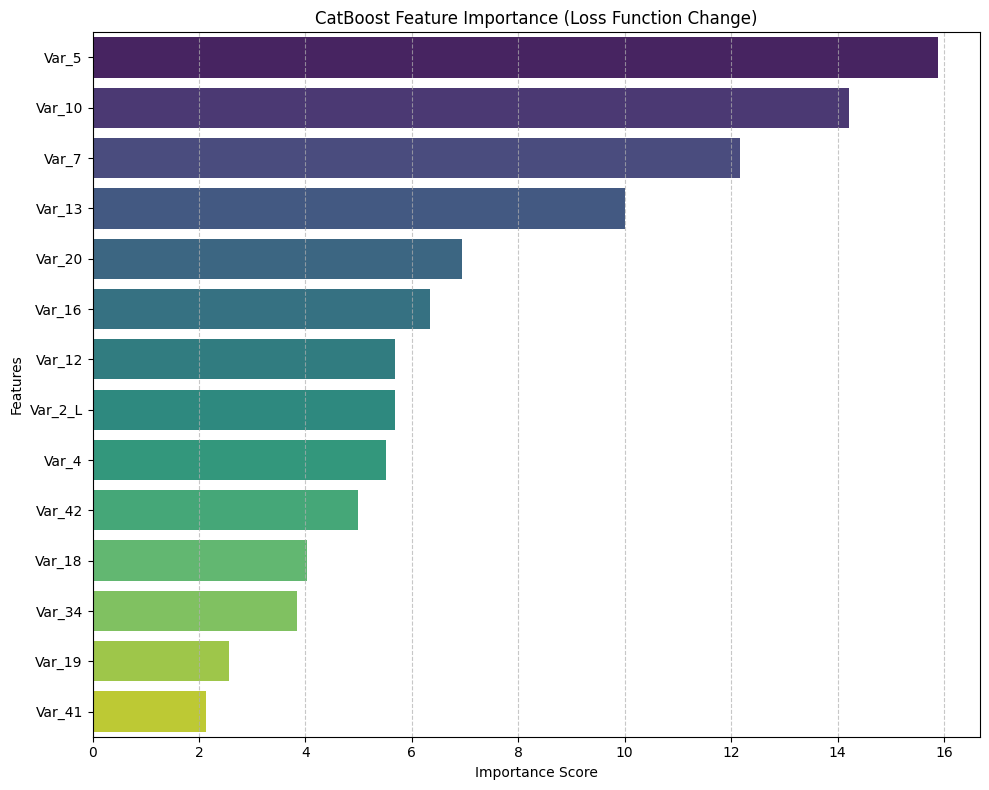

In [35]:
plot_catboost_importance(best_model, selected_features)

## OOF tahmini

Notebook'un başında ayırdığımız modelin hiçbir zaman görmediği OOF verisinin sonuçları gayet yeterli seviyede. Yani model canlıya alındığında iyi bir performans gösterecek.

In [36]:
y_test_pred = best_model.predict_proba(X_test[features])[:, 1]

gini_test = (2 * roc_auc_score(y_test, y_test_pred)) - 1
pr_auc_test = average_precision_score(y_test, y_test_pred)
r10 = calculate_recall_at_k(y_test, y_test_pred, 10)
pr10 = calculate_precision_at_k(y_test, y_test_pred, 10)

res = {
    "GINI": gini_test, "PR_AUC": pr_auc_test,
     "Recall@10": r10,
    "Precision@10": pr10,
}

df_res = pd.DataFrame([res])

df_res.style.format("{:.4f}")\
    .background_gradient(cmap='Blues', axis=1)\
    .set_caption("Model OOF Performans Özeti")\
    .set_table_styles([{'selector': 'caption', 'props': [('color', 'black'), ('font-size', '16px'), ('font-weight', 'bold')]}])

,GINI,PR_AUC,Recall@10,Precision@10
0,0.5641,0.1421,0.3405,0.1623


# Calibration Check

Muhtemelen, **scale_pos_weight** parametresi yüzünden model **overconfident** davranıyor.

Bu sebeple modeli kalibre etmemiz gerekecek.

Ben isotonic kullandım çünkü **Isotonic Regression**, veri seti yeterince büyük olduğunda olasılık skorlarını herhangi bir parametrik varsayıma bağlı kalmadan, esnek bir şekilde gerçek gerçekleşme oranlarıyla eşleştirir.


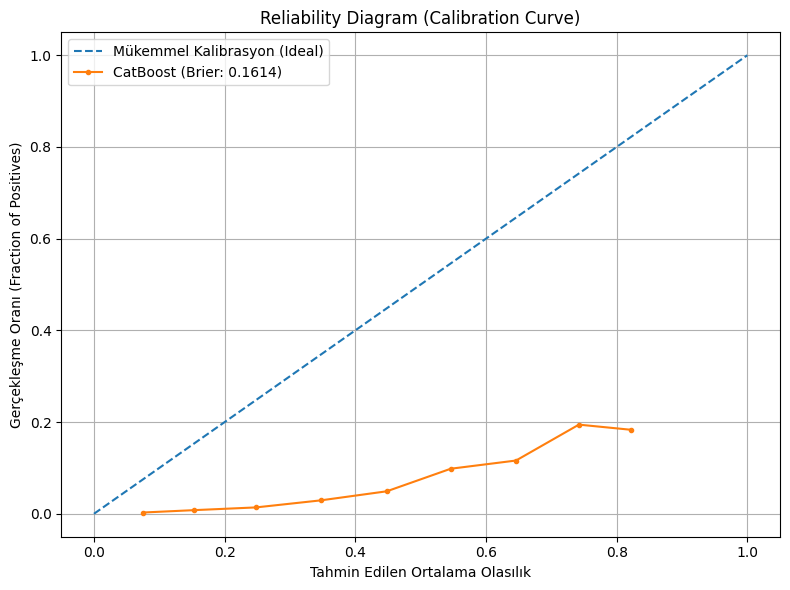

In [37]:
brier_score = check_calibration(best_model, X_test[selected_features], y_test)

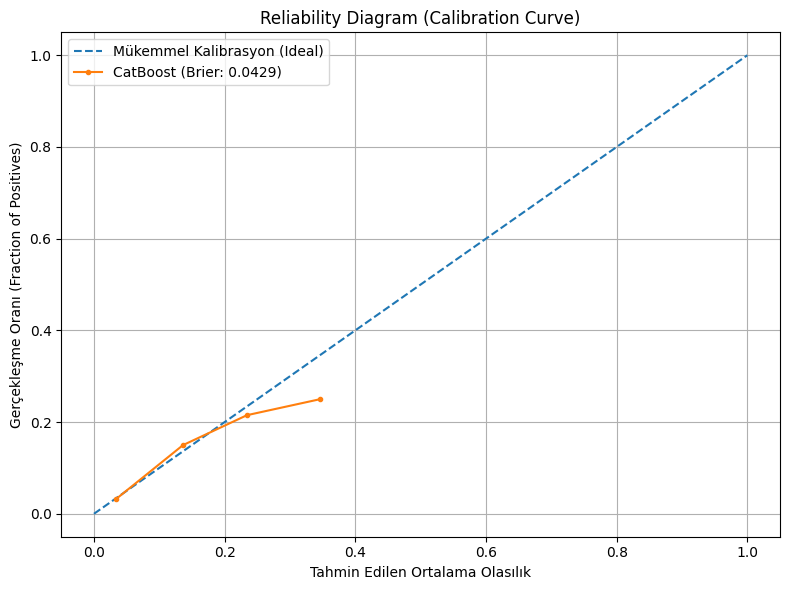

In [47]:
calibrated_model = isotonic_calibrator_catboost(train_df[selected_features], train_df[TARGET_COL], best_params, "isotonic", 2)
y_prob_calibrated = calibrated_model.predict_proba(X_test[selected_features])[:, 1]
brier_score = check_calibration(calibrated_model, X_test[selected_features], y_test)

## Confusion Matrix

Batan bir müşteriyi tahmin edemememin bedeli daha ağır olacağından **Recall** değerine önem verdim.

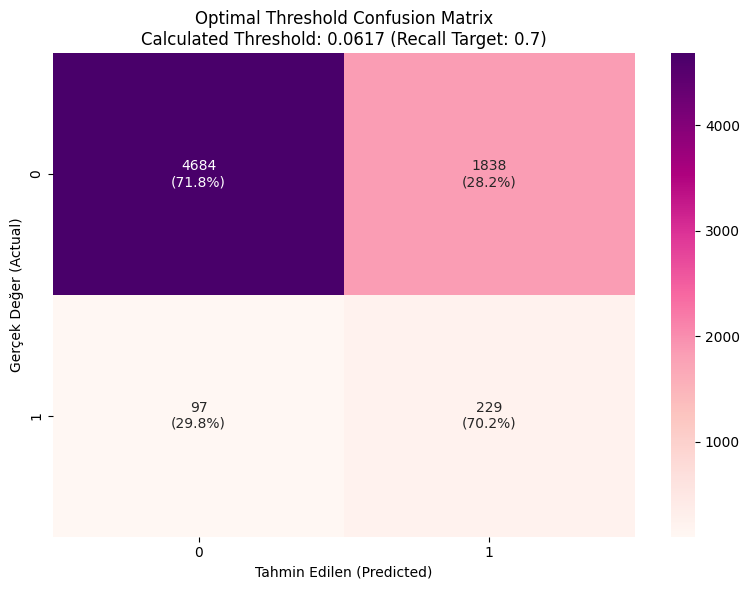

In [48]:
opt_threshold = plot_cm_with_optimal_pr_threshold(y_test, y_prob_calibrated)

In [49]:
opt_threshold

0.06169488566940129

Gözlemler:

- **Monotonluk** : En risksiz gruptan en riskli gruba default oranları monoton olarak artıyor.Bu, modelin "daha riskli" dediği grubun gerçekten daha fazla battığını kanıtlar.

- **Yüksek Lift** : En üst segmentteki default oranı (%16.62), en alt segmentten (%0.52) yaklaşık 38 kat daha fazla.

In [50]:
risk_report = create_risk_buckets(y_test, y_prob_calibrated)
display_styled_risk_report(risk_report)

,Min Olasılık,Max Olasılık,Gerçekleşen Default Oranı,Müşteri Sayısı
bucket,,,,
9,11.56%,37.14%,16.62%,668
8,8.93%,11.26%,9.66%,559
7,6.28%,8.74%,7.83%,741
6,3.96%,6.17%,5.51%,762
5,2.83%,3.96%,2.64%,683
4,1.81%,2.79%,2.53%,673
3,1.35%,1.80%,1.11%,633
2,1.35%,1.35%,1.98%,303
1,0.86%,1.35%,0.93%,861
